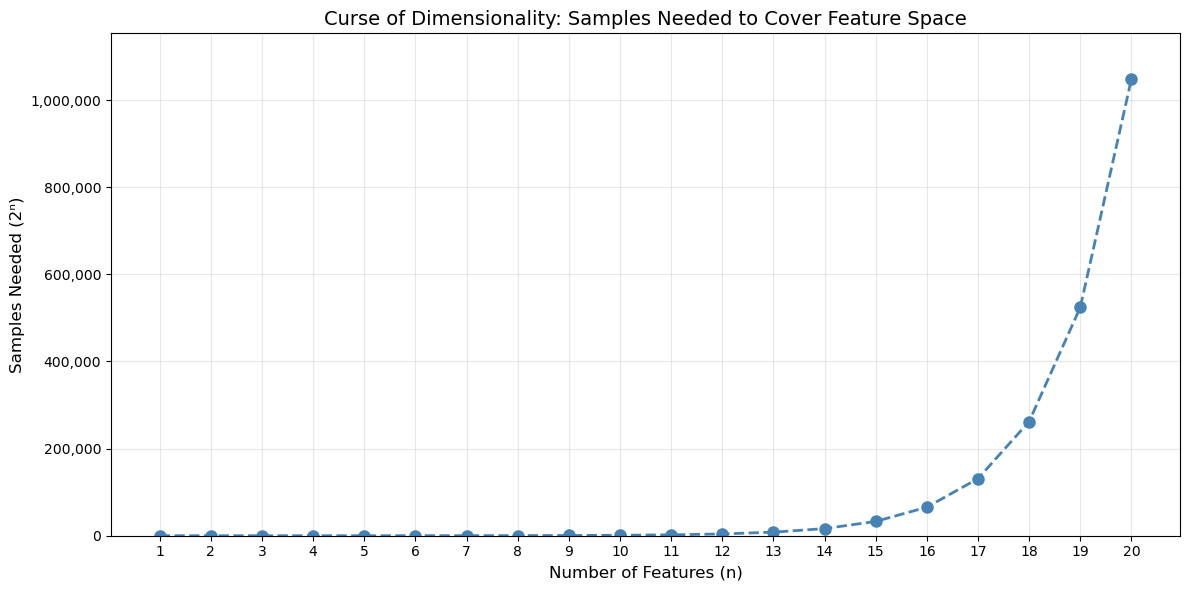

In [10]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 21)
samples = 2 ** n

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(n, samples, 'o--', color='steelblue', linewidth=2, markersize=8)

ax.set_xlabel('Number of Features (n)', fontsize=12)
ax.set_ylabel('Samples Needed (2ⁿ)', fontsize=12)
ax.set_title('Curse of Dimensionality: Samples Needed to Cover Feature Space', fontsize=14)
ax.set_xticks(n)
ax.set_ylim(0, 2**20 * 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def plot_curse(k=2, num_samples=1000):
    n = np.arange(1, 21)
    total_space = k ** n
    coverage = np.minimum(num_samples / total_space * 100, 100)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(n, coverage, color='steelblue', edgecolor='black')
    ax.set_xlabel('Number of Features (n)', fontsize=12)
    ax.set_ylabel('% of Space Covered', fontsize=12)
    ax.set_title(f'Curse of Dimensionality: {num_samples:,} samples, {k} values per feature', fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_xticks(n)
    ax.axhline(y=1, color='red', linestyle='--', label='1% coverage')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

interact(plot_curse, 
         k=IntSlider(min=2, max=20, step=1, value=2, description='Values/Feature'),
         num_samples=IntSlider(min=100, max=50000, step=100, value=1000, description='Samples'));

interactive(children=(IntSlider(value=2, description='Values/Feature', max=20, min=2), IntSlider(value=1000, d…

C:\Users\dasde\AppData\Local\Temp\ipykernel_23848\932040142.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


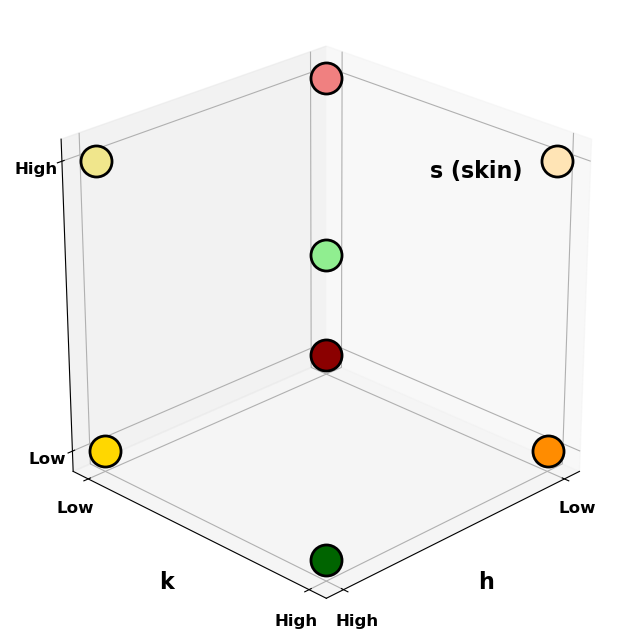

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

points = [
    (0, 0, 0, 'darkred'),      
    (0, 0, 1, 'lightcoral'),   
    (1, 0, 0, 'gold'),         
    (1, 0, 1, 'khaki'),        
    (0, 1, 0, 'darkorange'),   
    (0, 1, 1, 'moccasin'),     
    (1, 1, 0, 'darkgreen'),    
    (1, 1, 1, 'lightgreen'),   
]

for h, k, s, color in points:
    ax.scatter(h, k, s, s=500, c=color, edgecolors='black', linewidth=2)

ax.set_xlabel('h', fontsize=16, fontweight='bold')
ax.set_ylabel('k', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=12, fontweight='bold')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=12, fontweight='bold')
ax.set_zticks([0, 1])
ax.set_zticklabels(['Low', 'High'], fontsize=12, fontweight='bold')

# Manual z-label placement
ax.text(-0.5, 0, 0.5, 's (skin)', fontsize=16, fontweight='bold')

ax.set_box_aspect([1,1,1])
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

c:\Users\dasde\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dasde\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


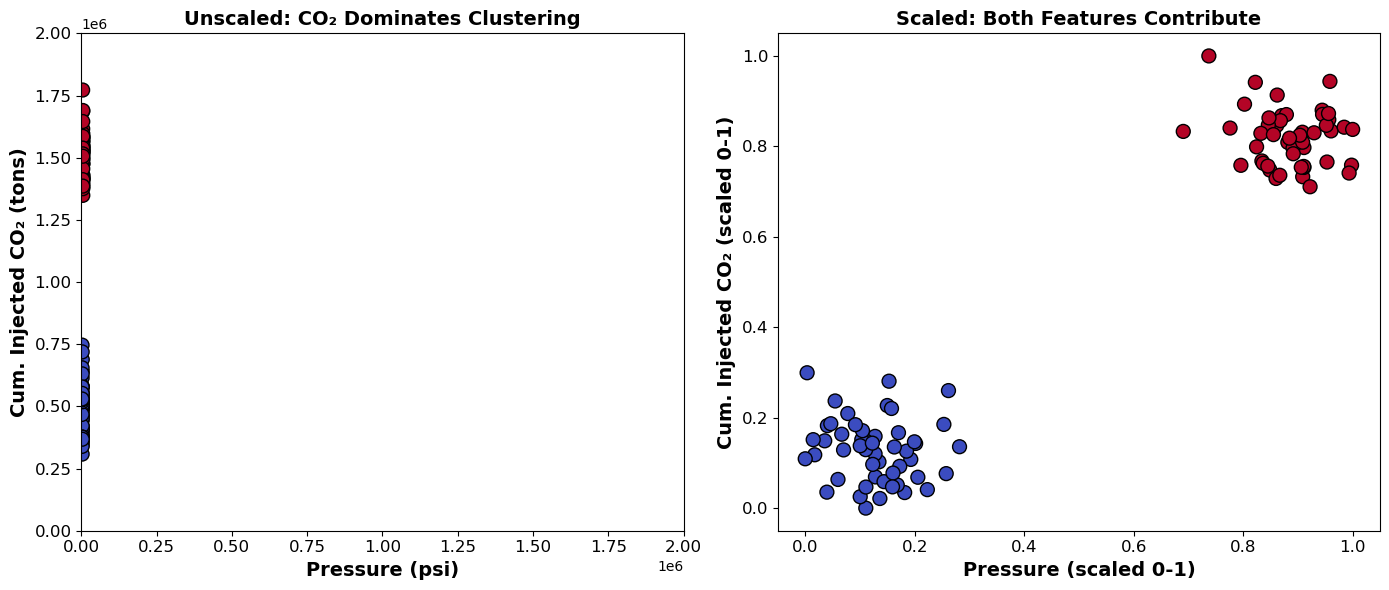

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(42)

n = 100
pressure = np.concatenate([np.random.normal(2500, 200, n//2), np.random.normal(4500, 200, n//2)])
cum_co2 = np.concatenate([np.random.normal(500000, 100000, n//2), np.random.normal(1500000, 100000, n//2)])

X_unscaled = np.column_stack([pressure, cum_co2])
X_scaled = np.column_stack([(pressure - pressure.min()) / (pressure.max() - pressure.min()),
                            (cum_co2 - cum_co2.min()) / (cum_co2.max() - cum_co2.min())])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unscaled
kmeans_unscaled = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_unscaled)
axes[0].scatter(pressure, cum_co2, c=kmeans_unscaled.labels_, cmap='coolwarm', s=100, edgecolors='black')
axes[0].set_xlabel('Pressure (psi)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cum. Injected CO₂ (tons)', fontsize=14, fontweight='bold')
axes[0].set_title('Unscaled: CO₂ Dominates Clustering', fontsize=14, fontweight='bold')
axes[0].tick_params(labelsize=12)
axes[0].set_xlim(0, 2000000)
axes[0].set_ylim(0, 2000000)

# Scaled
kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_scaled.labels_, cmap='coolwarm', s=100, edgecolors='black')
axes[1].set_xlabel('Pressure (scaled 0-1)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cum. Injected CO₂ (scaled 0-1)', fontsize=14, fontweight='bold')
axes[1].set_title('Scaled: Both Features Contribute', fontsize=14, fontweight='bold')
axes[1].tick_params(labelsize=12)

plt.tight_layout()
plt.show()